# Machine Learning

In [1]:
# === Instalações (se necessário) ===
%pip install xgboost --quiet
%pip install lightgbm --quiet
%pip install -U scikit-learn --quiet
%pip install scikit-survival --quiet
%pip install seaborn --quiet
%pip install --upgrade lifelines --quiet

# === Split ===
from sklearn.model_selection import train_test_split

# === Survival (scikit-survival) ===
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, integrated_brier_score, brier_score
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# === Encoders (você já usa) ===
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# === Métricas auxiliares de "tempo previsto" (quando existir) ===
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np
import pandas as pd

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 100, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "c:\python314\Lib\http\client.py", line 484, in read
    s = self.fp.read(amt)
  File "c:\python314\Lib\socket.py", line 725, in readinto
    return self._soc

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
df_colo = pd.read_csv('../DataSet/Colorretal_tratado_2025.csv', index_col=0)
df_colo

,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
INSTITU,,,,,,,,,,,,,,,,
9326,2,20,1,2,1,C182,IV,2019,1,9,2,2,0,Adenocarcinoma,33,1
12,4,20,2,9,2,C209,IV,2008,2,7,3,0,0,Adenocarcinoma,4,1
16624,5,20,2,2,2,C189,IV,2014,1,1,3,2,2,Adenocarcinoma,26,1
8672,4,20,2,2,1,C209,IV,2015,1,1,0,1,0,Adenocarcinoma,3,1
20737,4,20,2,2,2,C187,III,2016,1,2,3,0,0,Adenocarcinoma,61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612374,9,97,2,2,2,C209,III,2016,1,1,3,0,0,Adenocarcinoma,9,1
612374,9,99,2,2,2,C209,IV,2013,1,1,3,1,2,Adenocarcinoma,19,1
20621,2,99,1,2,2,C209,I,2016,2,3,3,0,0,Adenocarcinoma,17,1


In [ ]:
display(df_colo["time"])

,time
INSTITU,
9326,33
12,4
16624,26
8672,3
20737,61
...,...
612374,9
612374,19
20621,17


### Treino e Teste


In [ ]:
def split_train_test(df, test_size=0.2, random_state=19, stratify_col="event"):
    """
    Divide o dataframe em treino e teste.
    Para survival, é útil estratificar por event (0/1) para manter proporções.
    """
    df_aux = df.copy().reset_index(drop=True)

    strat = df_aux[stratify_col] if stratify_col in df_aux.columns else None

    df_train, df_test = train_test_split(
        df_aux,
        test_size=test_size,
        random_state=random_state,
        stratify=strat
    )
    return df_train.reset_index(drop=True), df_test.reset_index(drop=True)


### Encoders

In [ ]:
def fit_encoders_train(
    df_train,
    ordinal_col="ECGRUP",
    ordinal_order=("I", "II", "III", "IV"),
    onehot_cols=("TOPO", "MORFO_CAT"),
    drop_first=True
):
    """
    Ajusta (fit) os encoders SOMENTE no treino e devolve:
      - X_train_enc (com time/event)
      - encoders (oe, ohe)
      - feature_columns (colunas finais do X após encoding)
    """
    df_aux = df_train.copy().reset_index(drop=True)

    # ===== Ordinal =====
    oe = OrdinalEncoder(
        categories=[list(ordinal_order)],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    df_aux[[ordinal_col]] = oe.fit_transform(df_aux[[ordinal_col]])

    # ===== One-Hot =====
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        drop="first" if drop_first else None,
        sparse_output=False
    )

    X_ohe = ohe.fit_transform(df_aux[list(onehot_cols)])
    ohe_cols = ohe.get_feature_names_out(list(onehot_cols))
    df_ohe = pd.DataFrame(X_ohe, columns=ohe_cols, index=df_aux.index)

    # remove originais e concatena
    df_aux = df_aux.drop(columns=list(onehot_cols))
    X_train_enc = pd.concat([df_aux, df_ohe], axis=1)

    # bool -> int (segurança)
    for c in X_train_enc.columns:
        if X_train_enc[c].dtype == "bool":
            X_train_enc[c] = X_train_enc[c].astype(int)

    encoders = {"ordinal": oe, "onehot": ohe, "ordinal_col": ordinal_col, "onehot_cols": onehot_cols}
    feature_columns = X_train_enc.columns.tolist()

    return X_train_enc, encoders, feature_columns


def transform_with_encoders(df_test, encoders, feature_columns):
    """
    Aplica os encoders do treino no teste (apenas transform).
    Também alinha as colunas finais exatamente como no treino.
    """
    df_aux = df_test.copy().reset_index(drop=True)

    oe = encoders["ordinal"]
    ohe = encoders["onehot"]
    ordinal_col = encoders["ordinal_col"]
    onehot_cols = encoders["onehot_cols"]

    # ===== Ordinal transform =====
    df_aux[[ordinal_col]] = oe.transform(df_aux[[ordinal_col]])

    # ===== One-Hot transform =====
    X_ohe = ohe.transform(df_aux[list(onehot_cols)])
    ohe_cols = ohe.get_feature_names_out(list(onehot_cols))
    df_ohe = pd.DataFrame(X_ohe, columns=ohe_cols, index=df_aux.index)

    df_aux = df_aux.drop(columns=list(onehot_cols))
    X_test_enc = pd.concat([df_aux, df_ohe], axis=1)

    # bool -> int
    for c in X_test_enc.columns:
        if X_test_enc[c].dtype == "bool":
            X_test_enc[c] = X_test_enc[c].astype(int)

    # ===== Alinhar colunas com treino =====
    # cria colunas faltantes no teste com 0
    for col in feature_columns:
        if col not in X_test_enc.columns:
            X_test_enc[col] = 0

    # remove colunas extras (se surgirem por qualquer motivo)
    X_test_enc = X_test_enc[feature_columns]

    return X_test_enc


In [ ]:
# 1) split antes do encoder
df_train, df_test = split_train_test(df_colo, test_size=0.2, random_state=19, stratify_col="event")

# 2) fit encoders no treino
X_train_enc, encoders_ml, feature_cols = fit_encoders_train(
    df_train,
    ordinal_col="ECGRUP",
    ordinal_order=("I", "II", "III", "IV"),
    onehot_cols=("TOPO", "MORFO_CAT"),
    drop_first=True
)

# 3) transform no teste
X_test_enc = transform_with_encoders(df_test, encoders_ml, feature_cols)

print("Treino:", X_train_enc.shape, "| Teste:", X_test_enc.shape)
display(X_train_enc.head(3))
display(X_test_enc.head(3))


Treino: (26131, 28) | Teste: (6533, 28)


,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,2,67,1,2,2,2.0,2016,1,6,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,9,29,2,2,2,2.0,2019,2,3,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,64,1,9,2,3.0,2004,1,15,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,2,72,1,9,2,1.0,2010,1,9,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,52,2,9,1,1.0,2011,2,15,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,9,31,1,2,1,3.0,2016,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Divisão em X e y

In [ ]:
def make_sksurv_xy(X_enc, time_col="time", event_col="event"):
    """
    Converte dataframe codificado (com time/event) em:
      - X: covariáveis
      - y: Surv(dtype=[('event', '?'), ('time', '<f8')])
    """
    X = X_enc.drop(columns=[time_col, event_col]).copy()
    y = Surv.from_dataframe(event_col, time_col, X_enc)
    return X, y

X_train, y_train = make_sksurv_xy(X_train_enc, "time", "event")
X_test,  y_test  = make_sksurv_xy(X_test_enc, "time", "event")

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(26131, 26) (26131,) (6533, 26) (6533,)


In [ ]:
def calc_ipcw_cindex(y_train, y_test, risk_scores, tau=None):
    """
    Calcula o C-index IPCW.
    Se tau=None, usa automaticamente um tau seguro:
    o mínimo entre o maior tempo do teste e um valor ligeiramente menor
    que o maior tempo do treino.
    """
    if tau is None:
        tau = min(
            float(np.max(y_test["time"])),
            float(np.max(y_train["time"])) - 1e-8
        )

    cindex_ipcw = concordance_index_ipcw(
        y_train,
        y_test,
        risk_scores,
        tau=tau
    )[0]

    return float(cindex_ipcw)

## RSF

In [ ]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import brier_score
from sksurv.metrics import concordance_index_censored, integrated_brier_score

In [ ]:
def eval_survival_model_simple(model, X_train, y_train, X_test, y_test, max_time=60):
    # ---- C-index ----
    risk_test = model.predict(X_test)
    cindex = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]
    cindex_ipcw = calc_ipcw_cindex(y_train, y_test, risk_test, tau=max_time)

    # ---- Curvas e grid de tempos (via StepFunction) ----
    sfs = model.predict_survival_function(X_test, return_array=False)

    times_full = np.asarray(sfs[0].x, dtype=float)
    mask = (times_full > 0) & (times_full <= max_time)
    times = times_full[mask]

    surv = np.vstack([sf.y[mask] for sf in sfs]).astype(float)

    # ---- IBS ----
    ibs_val = integrated_brier_score(y_train, y_test, surv, times)

    # ---- Brier ao longo do tempo (e pega o último <= max_time) ----
    bs_times, bs_vals = brier_score(y_train, y_test, surv, times=times)
    brier_last = float(bs_vals[-1])
    t_last = int(bs_times[-1])

    return {
    "C-index": float(cindex),
    "C-index IPCW": float(cindex_ipcw),
    "IBS": float(ibs_val),
    f"Brier@{t_last}": brier_last
}

In [ ]:
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=19,
    oob_score=True
)
rsf.fit(X_train, y_train)

print("OOB score:", rsf.oob_score_)
rsf_metrics = eval_survival_model_simple(rsf, X_train, y_train, X_test, y_test, max_time=60)
rsf_metrics

OOB score: 0.7423146150178185


{'C-index': 0.7391117121336889,
 'C-index IPCW': 0.7376250433755168,
 'IBS': 0.15911055572546645,
 'Brier@60': 0.17772469307172897}

In [ ]:
results = {}
results["RSF"] = rsf_metrics
results

{'RSF': {'C-index': 0.7391117121336889,
  'C-index IPCW': 0.7376250433755168,
  'IBS': 0.15911055572546645,
  'Brier@60': 0.17772469307172897}}

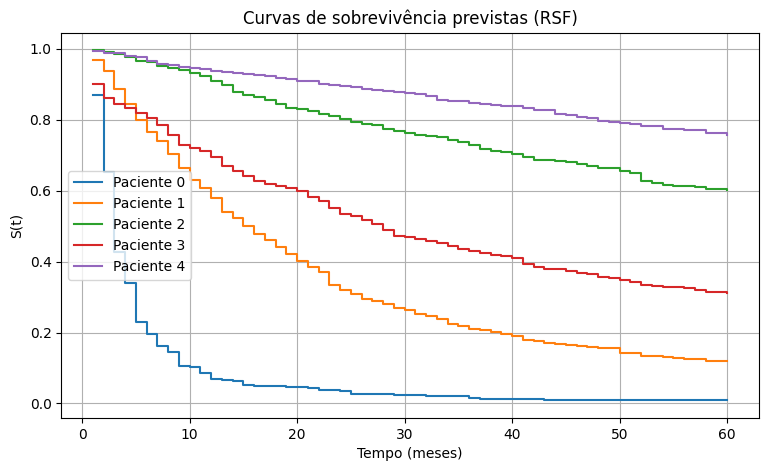

In [ ]:
import matplotlib.pyplot as plt

def plot_some_survival_curves(model, X_test, n=5, max_time=60):
    idx = np.random.RandomState(42).choice(len(X_test), size=min(n, len(X_test)), replace=False)
    sf = model.predict_survival_function(X_test.iloc[idx], return_array=False)

    plt.figure(figsize=(9,5))
    for i, fn in enumerate(sf):
        t = fn.x
        y = fn.y
        mask = t <= max_time
        plt.step(t[mask], y[mask], where="post", label=f"Paciente {i}")
    plt.xlabel("Tempo (meses)")
    plt.ylabel("S(t)")
    plt.title("Curvas de sobrevivência previstas (RSF)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_some_survival_curves(rsf, X_test, n=5, max_time=60)


## Gradient Boosting Survival

{'C-index': 0.7356945267276197, 'C-index IPCW': 0.7342955856742907, 'IBS': 0.160701048475027, 'Brier@60': 0.17964777258541756}


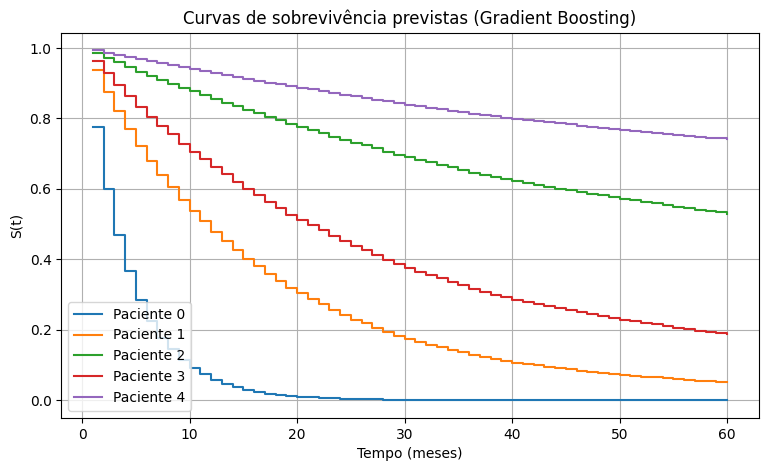

{'RSF': {'C-index': 0.7391117121336889,
  'C-index IPCW': 0.7376250433755168,
  'IBS': 0.15911055572546645,
  'Brier@60': 0.17772469307172897},
 'Gradient Boosting': {'C-index': 0.7356945267276197,
  'C-index IPCW': 0.7342955856742907,
  'IBS': 0.160701048475027,
  'Brier@60': 0.17964777258541756}}

In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, integrated_brier_score, brier_score
import numpy as np
import matplotlib.pyplot as plt

def eval_gbsa(model, X_train, y_train, X_test, y_test, max_time=60, tau=None):
    """
    Avalia GradientBoostingSurvivalAnalysis com:
      - C-index
      - C-index IPCW
      - IBS
      - Brier@último tempo <= max_time
    """

    # risco previsto
    risk_test = model.predict(X_test)

    # C-index (Harrell)
    cindex = concordance_index_censored(
        y_test["event"], y_test["time"], risk_test
    )[0]

    # tau seguro para IPCW
    if tau is None:
        tau = min(
            float(np.max(y_test["time"])),
            float(np.max(y_train["time"])) - 1e-8,
            float(max_time)
        )

    # C-index IPCW
    cindex_ipcw = concordance_index_ipcw(
        y_train,
        y_test,
        risk_test,
        tau=tau
    )[0]

    # curvas de sobrevivência
    sfs = model.predict_survival_function(X_test, return_array=False)

    times_full = np.asarray(sfs[0].x, dtype=float)
    mask = (times_full > 0) & (times_full <= max_time)
    times = times_full[mask]

    surv = np.vstack([sf.y[mask] for sf in sfs]).astype(float)

    # IBS
    ibs_val = integrated_brier_score(y_train, y_test, surv, times)

    # Brier Score ao longo do tempo
    bs_times, bs_vals = brier_score(y_train, y_test, surv, times=times)

    return {
        "C-index": float(cindex),
        "C-index IPCW": float(cindex_ipcw),
        "IBS": float(ibs_val),
        f"Brier@{int(bs_times[-1])}": float(bs_vals[-1]),
    }, times, surv, risk_test


def plot_some_gb_survival_curves(times, surv, n=5, seed=42, title="Curvas de sobrevivência previstas (Gradient Boosting)"):
    rng = np.random.RandomState(seed)
    idx = rng.choice(surv.shape[0], size=min(n, surv.shape[0]), replace=False)

    plt.figure(figsize=(9, 5))
    for i, k in enumerate(idx):
        plt.step(times, surv[k], where="post", label=f"Paciente {i}")
    plt.xlabel("Tempo (meses)")
    plt.ylabel("S(t)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


gbsa = GradientBoostingSurvivalAnalysis(
    loss="coxph",
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    max_depth=3,
    random_state=19
)

gbsa.fit(X_train, y_train)

metrics_gbsa, times_gbsa, surv_gbsa, risk_test_gbsa = eval_gbsa(
    gbsa,
    X_train, y_train,
    X_test, y_test,
    max_time=60,
    tau=60
)

print(metrics_gbsa)

plot_some_gb_survival_curves(
    times_gbsa,
    surv_gbsa,
    n=5,
    title="Curvas de sobrevivência previstas (Gradient Boosting)"
)

results["Gradient Boosting"] = metrics_gbsa
results

## XGBoost Cox

In [ ]:
import xgboost as xgb

def make_xgb_cox_label(y_struct):
    # y_struct é o Surv do scikit-survival
    t = y_struct["time"].astype(float)
    e = y_struct["event"].astype(bool)
    y = np.where(e, t, -t)  # censura -> negativo
    return y

dtrain = xgb.DMatrix(X_train, label=make_xgb_cox_label(y_train))
dtest  = xgb.DMatrix(X_test,  label=make_xgb_cox_label(y_test))

params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "tree_method": "hist",
    "learning_rate": 0.05,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "seed": 42,
}

bst_cox = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=50,
    verbose_eval=200
)


[0]	train-cox-nloglik:9.73948	test-cox-nloglik:8.35624
[200]	train-cox-nloglik:9.37040	test-cox-nloglik:8.03366
[257]	train-cox-nloglik:9.36044	test-cox-nloglik:8.03387


In [ ]:
# risco (quanto maior, pior sobrevida)
risk_test = bst_cox.predict(dtest)

cindex_xgb_cox = concordance_index_censored(
    y_test["event"], y_test["time"], risk_test
)[0]

cindex_xgb_cox

cindex_ipcw_xgb_cox = calc_ipcw_cindex(y_train, y_test, risk_test, tau=60)

In [ ]:
from lifelines import CoxPHFitter

def xgb_cox_survival_curves_via_lifelines(bst, X_train, y_train, X_test, y_test, max_time=60):
    # 1) pega "eta" (log-risk) no treino e no teste
    dtrain = xgb.DMatrix(X_train)
    dtest = xgb.DMatrix(X_test)
    eta_train = bst.predict(dtrain)  # score
    eta_test  = bst.predict(dtest)

    # 2) ajusta um CoxPHFitter com 1 covariável (eta) pra estimar baseline
    df_fit = pd.DataFrame({
        "eta": eta_train,
        "time": y_train["time"].astype(float),
        "event": y_train["event"].astype(int),
    })

    cph_eta = CoxPHFitter()
    cph_eta.fit(df_fit, duration_col="time", event_col="event")

    # 3) curvas S(t|eta) no teste
    df_test_eta = pd.DataFrame({"eta": eta_test})
    sf = cph_eta.predict_survival_function(df_test_eta)

    # 4) recorta até max_time e monta matriz (n, t)
    times = sf.index.values
    times = times[(times > 0) & (times <= max_time)]
    sf = sf.loc[times]
    surv = sf.T.values  # (n_samples, n_times)

    return times, surv

times, surv = xgb_cox_survival_curves_via_lifelines(bst_cox, X_train, y_train, X_test, y_test, max_time=60)

ibs_xgb_cox = integrated_brier_score(y_train, y_test, surv, times)
bs_times, bs_vals = brier_score(y_train, y_test, surv, times=times)

metrics_xgb_cox = {
    "C-index": float(concordance_index_censored(y_test["event"], y_test["time"], bst_cox.predict(xgb.DMatrix(X_test)))[0]),
    "C-index IPCW": float(calc_ipcw_cindex(y_train, y_test, bst_cox.predict(xgb.DMatrix(X_test)), tau=60)),
    "IBS": float(ibs_xgb_cox),
    f"Brier@{int(bs_times[-1])}": float(bs_vals[-1]),
}
metrics_xgb_cox


{'C-index': 0.7412529667637168,
 'C-index IPCW': 0.7397351678463064,
 'IBS': 0.1907409349429614,
 'Brier@60': 0.21733318510786462}

In [ ]:
bst_cox.best_iteration #

207

In [ ]:
results["XGBoost COX"] = metrics_xgb_cox
results

{'RSF': {'C-index': 0.7391117121336889,
  'C-index IPCW': 0.7376250433755168,
  'IBS': 0.15911055572546645,
  'Brier@60': 0.17772469307172897},
 'Gradient Boosting': {'C-index': 0.7356945267276197,
  'C-index IPCW': 0.7342955856742907,
  'IBS': 0.160701048475027,
  'Brier@60': 0.17964777258541756},
 'XGBoost COX': {'C-index': 0.7412529667637168,
  'C-index IPCW': 0.7397351678463064,
  'IBS': 0.1907409349429614,
  'Brier@60': 0.21733318510786462}}

## XGBoost AFT

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

from sksurv.metrics import concordance_index_censored, integrated_brier_score, brier_score
from lifelines import CoxPHFitter

In [ ]:
def make_aft_bounds(y_struct):
    """
    Evento: lower=upper=time
    Censura à direita: lower=time, upper=+inf
    """
    t = y_struct["time"].astype(float)
    e = y_struct["event"].astype(bool)
    lower = t.copy()
    upper = np.where(e, t, np.inf)
    return lower, upper


def make_dmatrix_aft(X, y_struct):
    """
    Cria DMatrix e seta label_lower_bound / label_upper_bound.
    """
    dmat = xgb.DMatrix(X)
    lower, upper = make_aft_bounds(y_struct)
    dmat.set_float_info("label_lower_bound", lower)
    dmat.set_float_info("label_upper_bound", upper)
    return dmat


dtrain_aft = make_dmatrix_aft(X_train, y_train)
dtest_aft  = make_dmatrix_aft(X_test,  y_test)

In [ ]:
def fit_xgb_aft(
    X_train, y_train, X_test, y_test,
    params=None,
    num_boost_round=6000,
    early_stopping_rounds=200,
    verbose_eval=200
):
    """
    Treina XGBoost AFT com validação no teste (early stopping).
    Retorna booster e DMatrices.
    """
    dtrain = make_dmatrix_aft(X_train, y_train)
    dtest  = make_dmatrix_aft(X_test,  y_test)

    if params is None:
        params = {
            "objective": "survival:aft",
            "eval_metric": "aft-nloglik",
            "aft_loss_distribution": "normal",
            "aft_loss_distribution_scale": 5.0,  # tende a ser mais estável
            "tree_method": "hist",
            "learning_rate": 0.05,
            "max_depth": 3,
            "min_child_weight": 50,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "lambda": 5.0,
            "alpha": 0.0,
            "seed": 42,
        }

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=[(dtrain, "train"), (dtest, "test")],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=verbose_eval
    )
    return bst, dtrain, dtest, params

In [ ]:
def aft_survival_curves_via_lifelines(bst_aft, X_train, y_train, X_test, max_time=60, penalizer=1e-3):
    """
    Usa o score do AFT (mu) como risco e calibra curvas com CoxPHFitter (1 covariável).
    Isso evita o problema de mu explodir e gerar S(t) ~ 1 constante.
    """
    # mu é a predição do AFT (escala log-tempo)
    mu_train = bst_aft.predict(xgb.DMatrix(X_train))
    mu_test  = bst_aft.predict(xgb.DMatrix(X_test))

    # risco: maior = pior sobrevida
    risk_train = -mu_train
    risk_test  = -mu_test

    # Ajusta Cox em 1 covariável (risk) para estimar baseline e obter S(t|risk)
    df_fit = pd.DataFrame({
        "risk": risk_train.astype(float),
        "time": y_train["time"].astype(float),
        "event": y_train["event"].astype(int),
    })

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(df_fit, duration_col="time", event_col="event")

    # Curvas no teste
    df_test = pd.DataFrame({"risk": risk_test.astype(float)})
    sf = cph.predict_survival_function(df_test)  # index = tempos

    # Recorta no horizonte e monta matriz (n_samples, n_times)
    times = sf.index.values.astype(float)
    mask = (times > 0) & (times <= max_time)
    times = times[mask]
    surv = sf.loc[times].T.values.astype(float)

    return times, surv, risk_test

In [ ]:
def eval_xgb_aft_calibrated(bst_aft, X_train, y_train, X_test, y_test, max_time=60):
    """
    Métricas:
      - C-index (Harrell) com risco = -mu
      - IBS e Brier@max_time usando curvas calibradas via lifelines
    """
    # risco do AFT para ranking (não usa exp)
    mu_test = bst_aft.predict(xgb.DMatrix(X_test))
    risk_test = -mu_test

    cindex = concordance_index_censored(
        y_test["event"], y_test["time"], risk_test
    )[0]

    cindex_ipcw = calc_ipcw_cindex(y_train, y_test, risk_test, tau=max_time)

    times, surv, _ = aft_survival_curves_via_lifelines(
        bst_aft, X_train, y_train, X_test, max_time=max_time
    )

    ibs_val = integrated_brier_score(y_train, y_test, surv, times)
    _, bs_vals = brier_score(y_train, y_test, surv, times=times)

    return {
    "C-index": float(cindex),
    "C-index IPCW": float(cindex_ipcw),
    "IBS": float(ibs_val),
    f"Brier@{int(times[-1])}": float(bs_vals[-1]),
}

In [ ]:
def plot_some_survival_curves_from_matrix(times, surv, n=5, seed=42, title="Curvas de sobrevivência previstas (XGB-AFT)"):
    rng = np.random.RandomState(seed)
    idx = rng.choice(surv.shape[0], size=min(n, surv.shape[0]), replace=False)

    plt.figure(figsize=(9, 5))
    for i, k in enumerate(idx):
        plt.step(times, surv[k], where="post", label=f"Paciente {i}")
    plt.xlabel("Tempo (meses)")
    plt.ylabel("S(t)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
bst_aft, dtrain_aft, dtest_aft, params_aft = fit_xgb_aft(
    X_train, y_train, X_test, y_test,
    params=None,                 # ou passe seu dict de params
    num_boost_round=6000,
    early_stopping_rounds=200,
    verbose_eval=200
)

[0]	train-aft-nloglik:3.63474	test-aft-nloglik:3.64685
[200]	train-aft-nloglik:3.04361	test-aft-nloglik:3.05687
[400]	train-aft-nloglik:3.04087	test-aft-nloglik:3.05515
[600]	train-aft-nloglik:3.03950	test-aft-nloglik:3.05475
[800]	train-aft-nloglik:3.03861	test-aft-nloglik:3.05458
[1000]	train-aft-nloglik:3.03787	test-aft-nloglik:3.05448
[1200]	train-aft-nloglik:3.03724	test-aft-nloglik:3.05443
[1400]	train-aft-nloglik:3.03670	test-aft-nloglik:3.05439
[1600]	train-aft-nloglik:3.03621	test-aft-nloglik:3.05425
[1800]	train-aft-nloglik:3.03578	test-aft-nloglik:3.05426
[1884]	train-aft-nloglik:3.03561	test-aft-nloglik:3.05424


In [ ]:
metrics_aft = eval_xgb_aft_calibrated(
    bst_aft,
    X_train, y_train,
    X_test, y_test,
    max_time=60
)
metrics_aft

{'C-index': 0.7295303660862748,
 'C-index IPCW': 0.7283045548828877,
 'IBS': 0.18974405228238841,
 'Brier@60': 0.2053897138427039}

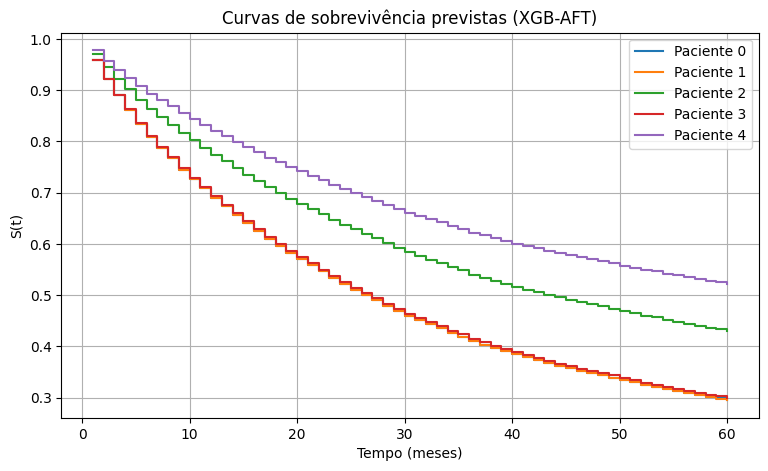

In [ ]:
times_aft, surv_aft, risk_test = aft_survival_curves_via_lifelines(
    bst_aft, X_train, y_train, X_test, max_time=60
)
plot_some_survival_curves_from_matrix(times_aft, surv_aft, n=5)

In [ ]:
print("risk_test min/med/max:", np.min(risk_test), np.median(risk_test), np.max(risk_test))
print("surv range:", np.min(surv_aft), np.max(surv_aft))
print("times:", times_aft[:5], "...", times_aft[-5:])

risk_test min/med/max: -295448.16 -298.85425 -1.1020774
surv range: 0.29393553293981717 1.0
times: [1. 2. 3. 4. 5.] ... [56. 57. 58. 59. 60.]


In [ ]:
results["XGBoost AFT"] = metrics_aft
results

{'RSF': {'C-index': 0.7391117121336889,
  'C-index IPCW': 0.7376250433755168,
  'IBS': 0.15911055572546645,
  'Brier@60': 0.17772469307172897},
 'Gradient Boosting': {'C-index': 0.7356945267276197,
  'C-index IPCW': 0.7342955856742907,
  'IBS': 0.160701048475027,
  'Brier@60': 0.17964777258541756},
 'XGBoost COX': {'C-index': 0.7412529667637168,
  'C-index IPCW': 0.7397351678463064,
  'IBS': 0.1907409349429614,
  'Brier@60': 0.21733318510786462},
 'XGBoost AFT': {'C-index': 0.7295303660862748,
  'C-index IPCW': 0.7283045548828877,
  'IBS': 0.18974405228238841,
  'Brier@60': 0.2053897138427039}}

## LightGBM Cox

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from lifelines import CoxPHFitter

from sksurv.metrics import concordance_index_censored, integrated_brier_score, brier_score

# (opcional) evitar warning do LightGBM sobre espaços no nome das features
X_train = X_train.copy()
X_test  = X_test.copy()
X_train.columns = X_train.columns.astype(str).str.replace(r"\s+", "_", regex=True)
X_test.columns  = X_test.columns.astype(str).str.replace(r"\s+", "_", regex=True)

In [ ]:
def _cox_group_denoms(time_sorted_desc, exp_f_sorted_desc):
    """
    Breslow para empates:
    ordene por tempo desc;
    denom é o cum_sum no fim de cada grupo de mesmo tempo.
    """
    cum_risk = np.cumsum(exp_f_sorted_desc)

    t = time_sorted_desc
    is_end = np.r_[t[1:] != t[:-1], True]
    group_end = np.where(is_end)[0]

    denom = np.empty_like(cum_risk)
    start = 0
    for end in group_end:
        denom_val = cum_risk[end]
        denom[start:end + 1] = denom_val
        start = end + 1
    return denom


def cox_negloglik_and_gradhess(pred, time, event):
    """
    Grad/Hess por amostra para Cox PH (neg partial loglik), Breslow ties.

    - Ordena por tempo desc.
    - Estabiliza f com clip.
    """
    time = time.astype(float)
    event = event.astype(np.int8)

    order = np.argsort(-time)  # desc
    inv = np.empty_like(order)
    inv[order] = np.arange(len(order))

    t_s = time[order]
    e_s = event[order]
    f_s = pred[order].astype(float)

    f_s = np.clip(f_s, -50.0, 50.0)
    exp_f = np.exp(f_s)

    denom = _cox_group_denoms(t_s, exp_f)
    denom = np.clip(denom, 1e-12, None)

    w = e_s / denom
    u = e_s / (denom ** 2)

    S = np.cumsum(w[::-1])[::-1]
    T = np.cumsum(u[::-1])[::-1]

    grad_s = exp_f * S - e_s
    hess_s = exp_f * S - (exp_f ** 2) * T
    hess_s = np.clip(hess_s, 1e-12, None)

    grad = grad_s[inv]
    hess = hess_s[inv]
    return grad, hess


def cox_negloglik_metric(pred, time, event):
    """
    Neg partial log-likelihood (Breslow ties), NORMALIZADO por #eventos.
    Isso deixa a escala estável e melhora o early stopping.
    """
    time = time.astype(float)
    event = event.astype(np.int8)

    order = np.argsort(-time)
    t_s = time[order]
    e_s = event[order]
    f_s = np.clip(pred[order].astype(float), -50.0, 50.0)

    exp_f = np.exp(f_s)
    denom = _cox_group_denoms(t_s, exp_f)
    denom = np.clip(denom, 1e-12, None)

    val = -np.sum(e_s * (f_s - np.log(denom)))
    n_events = max(1, int(e_s.sum()))
    return float(val / n_events)


In [ ]:
def fit_lgbm_cox(
    X_train, y_train,
    X_test, y_test,
    params=None,
    n_estimators=4000,
    early_stopping_rounds=100,
    verbose_eval=200
):
    time_tr = y_train["time"].astype(float)
    event_tr = y_train["event"].astype(bool).astype(np.int8)

    time_te = y_test["time"].astype(float)
    event_te = y_test["event"].astype(bool).astype(np.int8)

    if params is None:
        params = dict(
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=50,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            max_depth=-1,
            random_state=19,
            n_estimators=n_estimators
        )

    def custom_objective(y_true_time, y_pred):
        grad, hess = cox_negloglik_and_gradhess(y_pred, y_true_time, event_tr)
        return grad, hess

    def custom_metric(y_true_time, y_pred):
        # identifica train/test pelo tamanho
        e = event_tr if len(y_true_time) == len(time_tr) else event_te
        val = cox_negloglik_metric(y_pred, y_true_time, e)
        return ("cox-nloglik", val, False)  # menor é melhor

    model = lgb.LGBMRegressor(objective=custom_objective, **params)

    model.fit(
        X_train, time_tr,
        eval_set=[(X_train, time_tr), (X_test, time_te)],
        eval_names=["train", "test"],
        eval_metric=custom_metric,
        callbacks=[
            lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=True),
            lgb.log_evaluation(period=verbose_eval),
        ],
    )
    return model, params


In [ ]:
def _best_iter(model):
    # compatível com várias versões
    if hasattr(model, "best_iteration_") and model.best_iteration_ is not None:
        return int(model.best_iteration_)
    if hasattr(model, "booster_") and model.booster_ is not None:
        return int(model.booster_.best_iteration)
    return None


def lgbm_cox_survival_curves_via_lifelines(model, X_train, y_train, X_test, max_time=60, penalizer=1e-3):
    best_it = _best_iter(model)

    risk_train = model.predict(X_train, num_iteration=best_it).astype(float)
    risk_test  = model.predict(X_test,  num_iteration=best_it).astype(float)

    df_fit = pd.DataFrame({
        "risk": risk_train,
        "time": y_train["time"].astype(float),
        "event": y_train["event"].astype(int),
    })

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(df_fit, duration_col="time", event_col="event")

    sf = cph.predict_survival_function(pd.DataFrame({"risk": risk_test}))

    times = sf.index.values.astype(float)
    mask = (times > 0) & (times <= max_time)
    times = times[mask]
    surv = sf.loc[times].T.values.astype(float)

    return times, surv, risk_test


def eval_lgbm_cox(model, X_train, y_train, X_test, y_test, max_time=60):
    best_it = _best_iter(model)
    risk_test = model.predict(X_test, num_iteration=best_it).astype(float)

    cindex = concordance_index_censored(
        y_test["event"], y_test["time"], risk_test
    )[0]

    cindex_ipcw = calc_ipcw_cindex(y_train, y_test, risk_test, tau=max_time)

    times, surv, _ = lgbm_cox_survival_curves_via_lifelines(
        model, X_train, y_train, X_test, max_time=max_time
    )

    ibs_val = integrated_brier_score(y_train, y_test, surv, times)
    _, bs_vals = brier_score(y_train, y_test, surv, times=times)

    return {
    "C-index": float(cindex),
    "C-index IPCW": float(cindex_ipcw),
    "IBS": float(ibs_val),
    f"Brier@{int(times[-1])}": float(bs_vals[-1]),
}, times, surv, risk_test


In [ ]:
def plot_some_survival_curves_from_matrix(times, surv, n=5, seed=42, title="Curvas de sobrevivência previstas (LGBM-Cox)"):
    rng = np.random.RandomState(seed)
    idx = rng.choice(surv.shape[0], size=min(n, surv.shape[0]), replace=False)

    plt.figure(figsize=(9, 5))
    for i, k in enumerate(idx):
        plt.step(times, surv[k], where="post", label=f"Paciente {i}")
    plt.xlabel("Tempo (meses)")
    plt.ylabel("S(t)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 181
[LightGBM] [Info] Number of data points in the train set: 26131, number of used features: 26
[LightGBM] [Info] Using self-defined objective function
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	train's l2: 1839.59	train's cox-nloglik: 9.738	test's l2: 1836.93	test's cox-nloglik: 8.35503
{'C-index': 0.7178209253012824, 'C-index IPCW': 0.7163427973951866, 'IBS': 0.18007207699570005, 'Brier@60': 0.20347742991297602}


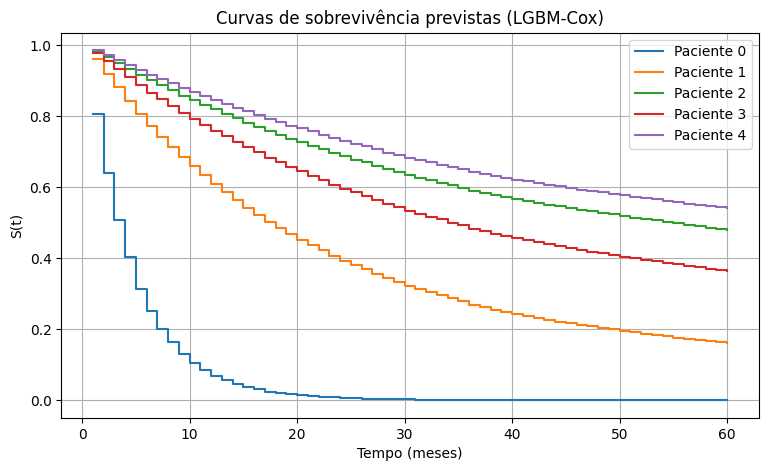

In [ ]:
bst_lgbm_cox, params_lgbm_cox = fit_lgbm_cox(
    X_train, y_train,
    X_test, y_test,
    params=None,
    n_estimators=4000,
    early_stopping_rounds=100,
    verbose_eval=200
)

metrics_lgbm_cox, times_lgbm, surv_lgbm, risk_test_lgbm = eval_lgbm_cox(
    bst_lgbm_cox,
    X_train, y_train,
    X_test, y_test,
    max_time=60
)

print(metrics_lgbm_cox)

plot_some_survival_curves_from_matrix(
    times_lgbm, surv_lgbm, n=5,
    title="Curvas de sobrevivência previstas (LGBM-Cox)"
)

In [ ]:
results["LGBM-Cox"] = metrics_lgbm_cox
results

{'RSF': {'C-index': 0.7391117121336889,
  'C-index IPCW': 0.7376250433755168,
  'IBS': 0.15911055572546645,
  'Brier@60': 0.17772469307172897},
 'Gradient Boosting': {'C-index': 0.7356945267276197,
  'C-index IPCW': 0.7342955856742907,
  'IBS': 0.160701048475027,
  'Brier@60': 0.17964777258541756},
 'XGBoost COX': {'C-index': 0.7412529667637168,
  'C-index IPCW': 0.7397351678463064,
  'IBS': 0.1907409349429614,
  'Brier@60': 0.21733318510786462},
 'XGBoost AFT': {'C-index': 0.7295303660862748,
  'C-index IPCW': 0.7283045548828877,
  'IBS': 0.18974405228238841,
  'Brier@60': 0.2053897138427039},
 'LGBM-Cox': {'C-index': 0.7178209253012824,
  'C-index IPCW': 0.7163427973951866,
  'IBS': 0.18007207699570005,
  'Brier@60': 0.20347742991297602}}

## Resultados

In [ ]:
def results_table(results_dict, sort_by="C-index", ascending=False):
    """
    Constrói tabela comparativa de métricas dos modelos de sobrevida.

    Parâmetros
    ----------
    results_dict : dict
        Ex:
        {
            "RSF": {"C-index": ..., "IBS": ..., "Brier@60": ...},
            "XGB-Cox": {...},
            ...
        }

    sort_by : str
        Métrica usada para ordenação (default = "C-index")

    ascending : bool
        Ordem crescente ou decrescente

    Retorno
    -------
    pandas.DataFrame
    """
    df = pd.DataFrame(results_dict).T

    # garante ordem padrão das colunas
    ordered_cols = [c for c in ["C-index", "C-index IPCW", "IBS", "Brier@60"] if c in df.columns]
    df = df[ordered_cols]

    df = df.sort_values(by=sort_by, ascending=ascending)
    return df

In [ ]:
table = results_table(results)
table

,C-index,C-index IPCW,IBS,Brier@60
XGBoost COX,0.741253,0.739735,0.190741,0.217333
RSF,0.739112,0.737625,0.159111,0.177725
Gradient Boosting,0.735695,0.734296,0.160701,0.179648
XGBoost AFT,0.729530,0.728305,0.189744,0.205390
LGBM-Cox,0.717821,0.716343,0.180072,0.203477
